In [1]:
# ==========================================
# CELL 1: ENVIRONMENT SETUP & IMPORTS
# ==========================================
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler
import torchvision.models as models, torchvision.transforms as transforms
from transformers import DistilBertTokenizer, DistilBertModel
from PIL import Image
import json, glob, os, re, time, random, pickle, warnings
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from collections import Counter
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MIXED_PRECISION = True if torch.cuda.is_available() else False

print(f"🔥 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cudnn.benchmark = True

JSON_DIR = "/media/youssef-abu-elmagd/SN580/Deep Learning Project /Working DataSet/NEW VQA"
IMAGE_DIR = "/media/youssef-abu-elmagd/SN580/Deep Learning Project /Working DataSet/Pictures"

IMG_SIZE = 224; BATCH_SIZE = 64; MAX_QUESTION_LENGTH = 64; FUSION_HIDDEN = 512
DROPOUT = 0.6; LEARNING_RATE = 2e-4; EARLY_STOPPING = 15; NUM_WORKERS = 4
PHASE1_EPOCHS = 10; PHASE2_EPOCHS = 50; NUM_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS
MIN_ANSWER_FREQ = 3

CHECKPOINT_DIR = "checkpoints_improved"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model_newdata_Copy.pt")
VOCAB_PATH = os.path.join(CHECKPOINT_DIR, "answer_vocab.pkl")

torch.manual_seed(42); np.random.seed(42); random.seed(42)

print(f"⚙️ Batch:{BATCH_SIZE} | Dropout:{DROPOUT} | LR:{LEARNING_RATE}")
print(f"⚙️ Epochs:{NUM_EPOCHS} (P1:{PHASE1_EPOCHS}+P2:{PHASE2_EPOCHS}) | EarlyStop:{EARLY_STOPPING}")

🔥 Device: cuda
   GPU: NVIDIA GeForce RTX 4050 Laptop GPU
   VRAM: 6.1 GB
⚙️ Batch:64 | Dropout:0.6 | LR:0.0002
⚙️ Epochs:60 (P1:10+P2:50) | EarlyStop:15


In [2]:
# ==========================================
# CELL 2: DATA LOADING & ANSWER CLEANING
# ==========================================
def clean_answer(text):
    text = text.strip().lower()
    text = re.sub(r'\b(one|1)\b', '1', text); text = re.sub(r'\b(two|2)\b', '2', text)
    text = re.sub(r'\b(three|3)\b', '3', text); text = re.sub(r'\b(four|4)\b', '4', text)
    text = re.sub(r'\b(five|5)\b', '5', text)
    text = text.replace('not specified', 'unknown').replace('not visible', 'no')
    text = text.replace('not present', 'no').replace('none', 'no')
    return re.sub(r'\s+', ' ', text).strip()

jsonl_files = sorted(glob.glob(f"{JSON_DIR}/*.jsonl"))
if not jsonl_files: raise FileNotFoundError(f"No .jsonl files found in {JSON_DIR}")

all_samples, image_descriptions = [], {}
file_stats = []
print(f"Found {len(jsonl_files)} .jsonl files:\n")

for file_path in jsonl_files:
    class_name = os.path.basename(file_path).replace('.jsonl','').replace('Filtered_VQA_','').replace('Raw_VQA_','').replace('_Final','').replace('Playlist_','').replace(' ','_')
    entries = []
    with open(file_path) as f:
        for line in f:
            if line.strip():
                item = json.loads(line.strip())
                entries.append(item)
                image_descriptions[item.get('image_id','')] = item.get('description','').lower()
    total_qa = 0
    for item in entries:
        for qa in item.get('qa_pairs', []):
            all_samples.append({
                'image_id': item.get('image_id','unknown'),
                'question': qa.get('question',''),
                'answer': clean_answer(qa.get('answer','')),
                'source_file': class_name
            })
            total_qa += 1
    file_stats.append({'name': class_name, 'images': len(entries), 'qa': total_qa})
    print(f"  {class_name}: {len(entries)} images, {total_qa} Q&A pairs")

print(f"\n📊 Total Q&A samples: {len(all_samples)}")
print(f"📊 Images with descriptions: {len(image_descriptions)}")
print(f"📊 Source files: {len(file_stats)}")

Found 18 .jsonl files:

  Bus: 207 images, 1279 Q&A pairs
  Children_Playing: 192 images, 966 Q&A pairs
  Cooking: 194 images, 1016 Q&A pairs
  Cycling: 149 images, 814 Q&A pairs
  Dogs: 83 images, 404 Q&A pairs
  Kitchen: 224 images, 1328 Q&A pairs
  Market: 234 images, 1241 Q&A pairs
  Office: 370 images, 1682 Q&A pairs
  Park: 153 images, 708 Q&A pairs
  People: 219 images, 1031 Q&A pairs
  Running: 117 images, 619 Q&A pairs
  Sports: 157 images, 799 Q&A pairs
  Street: 229 images, 1206 Q&A pairs
  Train: 177 images, 998 Q&A pairs
  car: 63 images, 314 Q&A pairs
  cat: 245 images, 1365 Q&A pairs
  fruits: 218 images, 1179 Q&A pairs
  vegetables: 208 images, 1101 Q&A pairs

📊 Total Q&A samples: 18050
📊 Images with descriptions: 3314
📊 Source files: 18


In [3]:
# ==========================================
# CELL 3: BUILD CATEGORICAL ANSWER VOCABULARY
# ==========================================
all_answers = [s['answer'] for s in all_samples]
answer_counts = Counter(all_answers)
print(f"📊 Unique answers: {len(answer_counts)}")

def is_categorical_answer(text):
    """Strict filter for classification-compatible answers."""
    text = text.strip().lower()
    cleaned = text.replace(' ', '')
    if cleaned.isdigit():
        try:
            if int(cleaned) <= 20: return True
        except ValueError: pass
    if text in ['yes', 'no', 'unknown']: return True
    words = text.split()
    if len(words) <= 2: return True
    if len(words) == 3:
        if text in ['in the background', 'on the left', 'on the right', 
                    'a few people', 'a train station', 'a modern kitchen',
                    'out of focus', 'in the distance']:
            return True
        return False
    return False

categorical_answers = {ans: count for ans, count in answer_counts.items() 
                       if is_categorical_answer(ans) and count >= MIN_ANSWER_FREQ}

print(f"\n📊 Categorical answers: {len(categorical_answers)} (removed {len(answer_counts)-len(categorical_answers)})")

print(f"\n🏆 Top 20 Answers:")
for i, (ans, count) in enumerate(sorted(categorical_answers.items(), key=lambda x: -x[1])[:20]):
    print(f"   {i+1:2d}. {ans:<25} → {count}x")

vocab_answers = sorted(categorical_answers.keys())
answer_to_idx = {ans: i for i, ans in enumerate(vocab_answers)}
idx_to_answer = {i: ans for ans, i in answer_to_idx.items()}

UNK_TOKEN = "<unk>"
answer_to_idx[UNK_TOKEN] = len(answer_to_idx)
idx_to_answer[len(answer_to_idx)-1] = UNK_TOKEN
NUM_ANSWERS = len(answer_to_idx)

unknown_count = 0
for s in all_samples:
    if s['answer'] in answer_to_idx:
        s['answer_idx'] = answer_to_idx[s['answer']]
    else:
        s['answer_idx'] = answer_to_idx[UNK_TOKEN]
        unknown_count += 1

print(f"\n✅ Final Vocabulary: {NUM_ANSWERS} classes (including <unk>)")
print(f"   <unk> rate: {unknown_count}/{len(all_samples)} ({unknown_count/len(all_samples):.1%})")

# Save vocabulary
with open(VOCAB_PATH, 'wb') as f:
    pickle.dump({'answer_to_idx': answer_to_idx, 'idx_to_answer': idx_to_answer}, f)
print(f"💾 Vocabulary saved to {VOCAB_PATH}")

📊 Unique answers: 382

📊 Categorical answers: 374 (removed 8)

🏆 Top 20 Answers:
    1. green                     → 641x
    2. 2                         → 618x
    3. red                       → 538x
    4. sunny                     → 495x
    5. 1                         → 490x
    6. blue                      → 476x
    7. calm                      → 473x
    8. no                        → 453x
    9. white                     → 451x
   10. several                   → 439x
   11. wood                      → 417x
   12. outdoor                   → 374x
   13. indoor                    → 373x
   14. market                    → 371x
   15. daytime                   → 325x
   16. kitchen                   → 307x
   17. 3                         → 295x
   18. background                → 288x
   19. yellow                    → 257x
   20. yes                       → 246x

✅ Final Vocabulary: 375 classes (including <unk>)
   <unk> rate: 81/18050 (0.4%)
💾 Vocabulary saved to checkpoints_imp

In [4]:
# ==========================================
# CELL 4 (FINAL): SEMANTIC ANSWER MAPPER - COMPLETE
# ==========================================
class SemanticAnswerMapper:
    """Maps semantically equivalent answers for training on semantic groups"""
    
    def __init__(self):
        self.semantic_groups = {
            # ============ WEATHER ============
            'weather_clear': ['clear', 'sunny', 'bright', 'fair', 'clear sky', 'sunny day', 'clear sunny'],
            'weather_cloudy': ['cloudy', 'overcast', 'gray sky', 'cloudy sky', 'gloomy', 'grey sky'],
            'weather_rainy': ['rainy', 'raining', 'wet', 'drizzle', 'rain'],
            
            # ============ TIME ============
            'time_day': ['daytime', 'day', 'during day', 'daylight', 'morning', 'afternoon'],
            'time_night': ['night', 'nighttime', 'evening', 'at night'],
            
            # ============ SCENE TYPES ============
            'scene_outdoor': ['outdoor', 'outside', 'open air', 'exterior', 'outdoors'],
            'scene_indoor': ['indoor', 'inside', 'interior', 'indoors'],
            'scene_urban': ['urban', 'city', 'downtown', 'city street', 'urban street', 
                           'metropolitan', 'european city', 'city center', 'urban area'],
            'scene_rural': ['rural', 'countryside', 'farm', 'village', 'country', 'rural road'],
            'scene_street': ['street', 'street scene', 'paved road', 'road', 'on road', 'lining street'],
            'scene_market': ['market', 'marketplace', 'outdoor market', 'market stall', 'market stalls'],
            'scene_park': ['park', 'park scene', 'garden', 'playground', 'park bench'],
            'scene_kitchen': ['kitchen', 'a modern kitchen', 'kitchen area'],
            'scene_office': ['office', 'office space', 'office room', 'office building'],
            'scene_station': ['train station', 'a train station', 'station', 'platform'],
            'scene_field': ['field', 'sports field', 'playing field'],
            'scene_beach': ['beach', 'seaside', 'near water', 'coast'],
            'scene_forest': ['forest', 'woods', 'wooded area'],
            
            # ============ COLORS ============
            'color_green': ['green', 'dark green', 'light green', 'greenish'],
            'color_red': ['red', 'dark red', 'bright red', 'reddish'],
            'color_blue': ['blue', 'dark blue', 'light blue', 'navy', 'bluish'],
            'color_white': ['white', 'bright white', 'off-white', 'whitish', 'pale'],
            'color_black': ['black', 'very dark', 'blackish', 'dark'],
            'color_gray': ['gray', 'grey', 'dark gray', 'light gray', 'silver'],
            'color_yellow': ['yellow', 'golden', 'yellowish'],
            'color_brown': ['brown', 'dark brown', 'light brown', 'beige'],
            'color_orange': ['orange', 'dark orange', 'bright orange'],
            'color_pink': ['pink', 'light pink'],
            'color_purple': ['purple', 'violet'],
            
            # ============ COUNTS ============
            'count_single': ['1', 'one', 'single', 'just one', 'only one'],
            'count_two': ['2', 'two', 'couple', 'a couple'],
            'count_few': ['3', 'three', 'few', 'a few'],
            'count_several': ['several', '4', 'four', 'multiple', 'various', 'numerous'],
            'count_many': ['many', 'lots', '5', 'five', 'six', '7', '8', '9', '10'],
            
            # ============ ACTIONS ============
            'action_moving': ['moving', 'in motion', 'driving', 'traveling', 'going', 'moving fast'],
            'action_stationary': ['stationary', 'still', 'parked', 'stopped', 'not moving', 'standing still'],
            'action_walking': ['walking', 'strolling', 'on foot', 'walking towards'],
            'action_standing': ['standing', 'posing'],
            'action_sitting': ['sitting', 'seated'],
            'action_cycling': ['cycling', 'biking', 'riding bike', 'pedaling', 'riding', '3 cyclists'],
            'action_running': ['running', 'jogging', 'sprinting'],
            'action_cooking': ['cooking', 'preparing food', 'making food'],
            'action_playing': ['playing', 'children playing'],
            'action_shopping': ['shopping', 'browsing', 'buying', 'selling'],
            'action_eating': ['eating', 'dining', 'having meal'],
            'action_waiting': ['waiting', 'waiting for bus'],
            'action_working': ['working', 'typing', 'at work'],
            'action_resting': ['resting', 'lying', 'relaxing', 'lounging'],
            
            # ============ MOOD/ATMOSPHERE ============
            'mood_calm': ['calm', 'peaceful', 'quiet', 'serene', 'tranquil', 'relaxed', 'resting', 'lying', 'casual'],
            'mood_busy': ['busy', 'bustling', 'crowded', 'lively', 'active', 'hectic', 'vibrant'],
            'mood_cheerful': ['cheerful', 'happy', 'positive', 'energetic'],
            'mood_warm': ['warm', 'cozy', 'inviting', 'comfortable'],
            
            # ============ MATERIALS ============
            'material_wood': ['wood', 'wooden', 'made of wood', 'timber'],
            'material_metal': ['metal', 'metallic', 'steel', 'iron'],
            'material_glass': ['glass', 'glassy', 'made of glass'],
            'material_brick': ['brick', 'bricks', 'brick building'],
            'material_concrete': ['concrete', 'cement', 'paved'],
            'material_stone': ['stone', 'rock', 'stones'],
            'material_plastic': ['plastic'],
            'material_steel': ['stainless steel'],
            
            # ============ POSITIONS ============
            'position_left': ['left', 'on the left', 'left side', 'to the left'],
            'position_right': ['right', 'on the right', 'right side', 'to the right'],
            'position_center': ['center', 'middle', 'in center', 'centered'],
            'position_background': ['background', 'in background', 'behind', 'at back', 'in the background'],
            'position_foreground': ['foreground', 'in front', 'front', 'at front', 'in the foreground'],
            'position_distance': ['in the distance', 'far away', 'out of focus'],
            
            # ============ OBJECTS ============
            'object_bus': ['bus', 'buses', 'city bus', 'double decker bus', 'near bus'],
            'object_car': ['car', 'cars', 'vehicle', 'automobile', 'vehicles'],
            'object_train': ['train', 'trains'],
            'object_bicycle': ['bicycle', 'bicycles', 'bike', 'bikes'],
            'object_motorcycle': ['motorcycle', 'motorbike'],
            'object_truck': ['truck', 'lorry'],
            
            'object_person': ['person', 'people', 'pedestrian', 'pedestrians', 'human', 
                             'individuals', 'several people', 'a few people', 'man', 'woman',
                             'male', 'female', 'adult', 'child', 'children', 'group'],
            'object_dog': ['dog', 'dogs', 'puppy', 'puppies'],
            'object_cat': ['cat', 'cats', 'kitten', 'kittens'],
            
            'object_tree': ['tree', 'trees'],
            'object_building': ['building', 'buildings', 'modern building', 'tall building'],
            'object_house': ['house', 'home', 'residential'],
            
            'object_food': ['fruit', 'fruits', 'vegetable', 'vegetables', 'food', 'produce'],
            'object_table': ['table', 'tables', 'desk'],
            'object_chair': ['chair', 'chairs', 'seats', 'bench'],
            'object_sign': ['sign', 'traffic light', 'traffic lights', 'streetlights', 
                           'street lamp', 'bus stop', 'signage'],
            'object_umbrella': ['umbrella', 'umbrellas', 'under canopy'],
            'object_water': ['water', 'river', 'lake', 'fountain', 'pond'],
            'object_window': ['window', 'windows'],
            'object_sidewalk': ['sidewalk', 'sidewalks', 'pavement'],
            'object_display': ['display', 'displays', 'screen', 'monitor'],
            'object_stall': ['stall', 'stalls'],
            
            # ============ ATTRIBUTES ============
            'attribute_natural': ['natural', 'nature', 'natural light', 'organic'],
            'attribute_artificial': ['artificial', 'synthetic', 'artificial light', 'man-made'],
            'attribute_vibrant': ['vibrant', 'vivid', 'colorful', 'bright colors'],
            'attribute_muted': ['earthy tones', 'muted tones', 'muted', 'neutral tones', 'neutral'],
            'attribute_warm': ['warm', 'cozy'],
            
            # ============ YES/NO ============
            'yes': ['yes', 'present', 'visible'],
            'no': ['no', 'not visible', 'not present', 'none', 'not specified', 'unknown'],
        }
        
        self.answer_to_group = {}
        for group_id, answers in self.semantic_groups.items():
            for answer in answers:
                self.answer_to_group[answer.lower().strip()] = group_id
        
        self.group_display = {
            # Weather
            'weather_clear': 'clear/bright', 'weather_cloudy': 'cloudy/overcast',
            'weather_rainy': 'rainy/wet',
            # Time
            'time_day': 'daytime', 'time_night': 'nighttime',
            # Scenes
            'scene_outdoor': 'outdoor', 'scene_indoor': 'indoor',
            'scene_urban': 'urban/city', 'scene_rural': 'rural',
            'scene_street': 'street/road', 'scene_market': 'market',
            'scene_park': 'park/garden', 'scene_kitchen': 'kitchen',
            'scene_office': 'office', 'scene_station': 'station',
            'scene_field': 'field', 'scene_beach': 'beach/water',
            'scene_forest': 'forest',
            # Colors
            'color_green': 'green', 'color_red': 'red', 'color_blue': 'blue',
            'color_white': 'white', 'color_black': 'black', 'color_gray': 'gray',
            'color_yellow': 'yellow', 'color_brown': 'brown', 'color_orange': 'orange',
            'color_pink': 'pink', 'color_purple': 'purple',
            # Counts
            'count_single': 'one', 'count_two': 'two', 'count_few': 'few',
            'count_several': 'several', 'count_many': 'many',
            # Actions
            'action_moving': 'moving', 'action_stationary': 'stationary',
            'action_walking': 'walking', 'action_standing': 'standing',
            'action_sitting': 'sitting', 'action_cycling': 'cycling',
            'action_running': 'running', 'action_cooking': 'cooking',
            'action_playing': 'playing', 'action_shopping': 'shopping',
            'action_eating': 'eating', 'action_waiting': 'waiting',
            'action_working': 'working', 'action_resting': 'resting',
            # Mood
            'mood_calm': 'calm/peaceful', 'mood_busy': 'busy/lively',
            'mood_cheerful': 'cheerful/happy', 'mood_warm': 'warm/cozy',
            # Materials
            'material_wood': 'wood', 'material_metal': 'metal',
            'material_glass': 'glass', 'material_brick': 'brick',
            'material_concrete': 'concrete', 'material_stone': 'stone',
            'material_plastic': 'plastic', 'material_steel': 'steel',
            # Positions
            'position_left': 'left', 'position_right': 'right',
            'position_center': 'center', 'position_background': 'background',
            'position_foreground': 'foreground', 'position_distance': 'distance',
            # Objects
            'object_bus': 'bus', 'object_car': 'car/vehicle',
            'object_train': 'train', 'object_bicycle': 'bicycle',
            'object_motorcycle': 'motorcycle', 'object_truck': 'truck',
            'object_person': 'person/people', 'object_dog': 'dog',
            'object_cat': 'cat', 'object_tree': 'trees',
            'object_building': 'building', 'object_house': 'house',
            'object_food': 'food/produce', 'object_table': 'table/desk',
            'object_chair': 'chair/seat', 'object_sign': 'signs/lights',
            'object_umbrella': 'umbrella', 'object_water': 'water',
            'object_window': 'window', 'object_sidewalk': 'sidewalk',
            'object_display': 'display/screen', 'object_stall': 'stalls',
            # Attributes
            'attribute_natural': 'natural', 'attribute_artificial': 'artificial',
            'attribute_vibrant': 'vibrant/colorful', 'attribute_muted': 'muted/earthy',
            'attribute_warm': 'warm',
            # Yes/No
            'yes': 'yes', 'no': 'no',
        }
    
    def get_semantic_group(self, answer):
        return self.answer_to_group.get(answer.lower().strip(), None)
    
    def get_group_display(self, answer):
        group = self.get_semantic_group(answer)
        if group:
            return self.group_display.get(group, group)
        return answer

semantic_mapper = SemanticAnswerMapper()
print("✅ Semantic mapper initialized!")
print(f"   Groups: {len(semantic_mapper.semantic_groups)}")
print(f"   Mapped answers: {len(semantic_mapper.answer_to_group)}")

✅ Semantic mapper initialized!
   Groups: 95
   Mapped answers: 394


In [5]:
# ==========================================
# CELL 5 (FIXED): TRAIN ON SEMANTIC GROUPS
# ==========================================

# Save original mappings for reference
idx_to_answer_backup = idx_to_answer.copy()

# Build semantic classes from group_display values
semantic_classes = sorted(set(semantic_mapper.group_display.values()))
semantic_class_to_idx = {group: i for i, group in enumerate(semantic_classes)}

# Add UNK token
semantic_class_to_idx[UNK_TOKEN] = len(semantic_class_to_idx)
semantic_classes.append(UNK_TOKEN)

# Track unmapped answers
unmapped_answers = Counter()
mapped_count = 0
unk_count_final = 0

# Replace ALL sample answer indices with semantic group indices
for s in all_samples:
    orig_idx = s['answer_idx']
    answer_text = idx_to_answer_backup.get(orig_idx, UNK_TOKEN).strip()
    
    if answer_text == UNK_TOKEN:
        s['answer_idx'] = semantic_class_to_idx[UNK_TOKEN]
        unk_count_final += 1
        continue
    
    # Get the semantic group display name
    # This method finds the group, then returns the display name
    group_display = semantic_mapper.get_group_display(answer_text)
    
    if group_display in semantic_class_to_idx:
        s['answer_idx'] = semantic_class_to_idx[group_display]
        mapped_count += 1
    else:
        # Try direct lookup (in case answer was already a group name)
        if answer_text in semantic_class_to_idx:
            s['answer_idx'] = semantic_class_to_idx[answer_text]
            mapped_count += 1
        else:
            unmapped_answers[answer_text] += 1
            s['answer_idx'] = semantic_class_to_idx[UNK_TOKEN]
            unk_count_final += 1

# Update globals
ORIGINAL_NUM_ANSWERS = NUM_ANSWERS
NUM_ANSWERS = len(semantic_classes)
answer_to_idx = semantic_class_to_idx
idx_to_answer = {i: group for group, i in semantic_class_to_idx.items()}

# ============ DIAGNOSTICS ============
class_dist = Counter(s['answer_idx'] for s in all_samples)
unk_idx = semantic_class_to_idx[UNK_TOKEN]

print(f"\n🔥 TRAINING ON SEMANTIC GROUPS!")
print(f"   Original classes: {ORIGINAL_NUM_ANSWERS}")
print(f"   Semantic groups:  {NUM_ANSWERS} (including <unk>)")
print(f"   Mapped successfully: {mapped_count}/{len(all_samples)} ({mapped_count/len(all_samples):.1%})")
print(f"   Sent to UNK: {unk_count_final}/{len(all_samples)} ({unk_count_final/len(all_samples):.1%})")

# Non-UNK distribution
non_unk_dist = {k: v for k, v in class_dist.items() if k != unk_idx}
if non_unk_dist:
    mc_idx = max(non_unk_dist, key=non_unk_dist.get)
    lc_idx = min(non_unk_dist, key=non_unk_dist.get)
    print(f"\n📊 Class Distribution (excl. UNK):")
    print(f"   Most frequent: {non_unk_dist[mc_idx]} samples ({idx_to_answer[mc_idx]})")
    print(f"   Least frequent: {non_unk_dist[lc_idx]} samples ({idx_to_answer[lc_idx]})")
    print(f"   Imbalance ratio: {non_unk_dist[mc_idx]/non_unk_dist[lc_idx]:.1f}:1")

# Show unmapped if any
if len(unmapped_answers) > 0:
    total_unmapped = sum(unmapped_answers.values())
    print(f"\n⚠️  UNMAPPED ({len(unmapped_answers)} unique, {total_unmapped} total):")
    for i, (ans, count) in enumerate(unmapped_answers.most_common(15)):
        print(f"  '{ans}': {count}x")
    if len(unmapped_answers) > 15:
        print(f"  ... and {len(unmapped_answers)-15} more types")

# Verify
assert max(s['answer_idx'] for s in all_samples) < NUM_ANSWERS, \
    f"CRITICAL: answer_idx >= NUM_ANSWERS ({NUM_ANSWERS})"

print(f"\n✅ Semantic mapping complete! NUM_ANSWERS = {NUM_ANSWERS}")


🔥 TRAINING ON SEMANTIC GROUPS!
   Original classes: 375
   Semantic groups:  96 (including <unk>)
   Mapped successfully: 16190/18050 (89.7%)
   Sent to UNK: 1860/18050 (10.3%)

📊 Class Distribution (excl. UNK):
   Most frequent: 763 samples (calm/peaceful)
   Least frequent: 5 samples (rainy/wet)
   Imbalance ratio: 152.6:1

⚠️  UNMAPPED (186 unique, 1779 total):
  'living room': 35x
  'still life': 35x
  'on surface': 32x
  'countertop': 31x
  'tracks': 28x
  'lying down': 28x
  'soft': 27x
  'pot': 26x
  'domestic': 25x
  'marble': 25x
  'displayed': 24x
  'tall': 23x
  'focused': 23x
  'professional': 23x
  'warm tones': 22x
  ... and 171 more types

✅ Semantic mapping complete! NUM_ANSWERS = 96


In [6]:
# ==========================================
# CELL 5.5: UNMAPPED ANSWER DIAGNOSTIC
# ==========================================
print("\n🔍 ANALYZING UNMAPPED ANSWERS...")
print("="*60)

# Find which answers are mapping to UNK
unk_idx = semantic_class_to_idx[UNK_TOKEN]
unmapped = Counter()
for s in all_samples:
    if s['answer_idx'] == unk_idx:
        # Get the ORIGINAL answer text (before semantic mapping)
        # We need to trace back through the mapping
        answer_text = None
        for orig_text, orig_idx in answer_to_idx_backup.items():
            if orig_idx == s.get('_original_idx', -1):
                answer_text = orig_text
                break
        if answer_text:
            unmapped[answer_text] += 1
        else:
            unmapped["unknown_trace"] += 1

print(f"Top 30 unmapped answers (sending to <unk>):")
print("-"*60)
for i, (ans, count) in enumerate(unmapped.most_common(30)):
    pct = count / len(all_samples) * 100
    print(f"  {i+1:2d}. '{ans:<35}' → {count:>5}x ({pct:.1f}%)")

print(f"\n📊 Total unique unmapped: {len(unmapped)}")
print(f"📊 Total unmapped samples: {sum(unmapped.values())} ({sum(unmapped.values())/len(all_samples):.1%})")


🔍 ANALYZING UNMAPPED ANSWERS...


NameError: name 'answer_to_idx_backup' is not defined

In [4]:
# ==========================================
# CELL 6: VQA-SAFE AUGMENTATION
# ==========================================
class VQAAugmentor:
    def __init__(self, split='train'):
        self.augment = (split == 'train')
        if self.augment:
            self.image_transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.RandomAffine(degrees=5, translate=(0.05,0.05), scale=(0.95,1.05)),
                transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1,0.5))], p=0.2),
                transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
            ])
        else:
            self.image_transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
            ])
        self.synonyms = {
            'what':['what','which','what exactly'], 'where':['where','in what location','at what place'],
            'how many':['how many','count the','number of'], 'is there':['is there','are there','do you see','can you see'],
            'color':['color','colour','shade','hue'], 'car':['car','vehicle','automobile'],
            'person':['person','human','people'], 'setting':['setting','location','place','environment','scene'],
            'atmosphere':['atmosphere','mood','vibe','ambiance'], 'visible':['visible','shown','present','depicted'],
            'located':['located','positioned','situated','found'], 'describe':['describe','explain','tell me about'],
            'moving':['moving','in motion','driving','traveling'], 'stationary':['stationary','still','parked','motionless']
        }
        self.templates = ["{q}","Can you tell me {q_lower}?","I need to know {q_lower}.","Please describe {q_lower}."]
    
    def augment_question(self, question):
        if not self.augment: return question
        q = question.strip()
        if random.random() < 0.5:
            q_lower = q.lower()
            for word, syns in self.synonyms.items():
                if re.search(rf'\b{word}\b', q_lower) and random.random() < 0.3:
                    q_lower = re.sub(rf'\b{word}\b', random.choice(syns), q_lower)
            q = q_lower
        if random.random() < 0.2: q = random.choice(self.templates).format(q=q, q_lower=q.lower().rstrip('?.'))
        if random.random() < 0.3: q = q[:-1] + random.choice(['?','.']) if q.endswith('?') else q.rstrip('.') + '?'
        return q
    
    def transform_image(self, image): return self.image_transform(image)

print("✅ Augmentation module ready!")
print("   Image: Affine + Blur (train only)")
print("   Text: Synonym swapping + template variation")

✅ Augmentation module ready!
   Image: Affine + Blur (train only)
   Text: Synonym swapping + template variation


In [5]:
# ==========================================
# CELL 7: DATASET CLASS
# ==========================================
class VQADataset(Dataset):
    def __init__(self, samples, split='train'):
        self.samples = samples
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        self.augmentor = VQAAugmentor(split=split)
        self.image_cache = {}
        for f in glob.glob(os.path.join(IMAGE_DIR, "*")):
            if os.path.isfile(f): 
                self.image_cache[os.path.splitext(os.path.basename(f))[0]] = f
    
    def __len__(self): return len(self.samples)
    
    def _find_image(self, image_id):
        if image_id in self.image_cache: return self.image_cache[image_id]
        for ext in ['.jpg','.jpeg','.png','.webp','.JPG','.JPEG','.PNG']:
            path = os.path.join(IMAGE_DIR, image_id + ext)
            if os.path.exists(path): 
                self.image_cache[image_id] = path
                return path
        return None
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        path = self._find_image(s['image_id'])
        try: 
            image = Image.open(path).convert('RGB') if path else Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        except: 
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        image = self.augmentor.transform_image(image)
        question = self.augmentor.augment_question(s['question'])
        tokens = self.tokenizer(question, max_length=MAX_QUESTION_LENGTH, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'image': image,
            'input_ids': tokens['input_ids'].squeeze(0),
            'attention_mask': tokens['attention_mask'].squeeze(0),
            'answer': torch.tensor(s['answer_idx'], dtype=torch.long)
        }

print("✅ Dataset class defined!")

✅ Dataset class defined!


In [6]:
# ==========================================
# CELL 8: CNN ENCODER (MobileNetV3-Large)
# ==========================================
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        m = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
        self.features = m.features
        self.avgpool = m.avgpool
        self.projection = nn.Sequential(
            nn.Linear(960, FUSION_HIDDEN),
            nn.LayerNorm(FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.projection(x)

print(f"✅ CNN Encoder ready! Params: {sum(p.numel() for p in CNNEncoder().parameters()):,}")

✅ CNN Encoder ready! Params: 3,465,008


In [7]:
# ==========================================
# CELL 9: TEXT ENCODER (DistilBERT)
# ==========================================
class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.projection = nn.Sequential(
            nn.Linear(768, FUSION_HIDDEN),
            nn.LayerNorm(FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT)
        )
    
    def forward(self, input_ids, attention_mask):
        return self.projection(
            self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        )

print(f"✅ Text Encoder ready! Params: {sum(p.numel() for p in TextEncoder().parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Text Encoder ready! Params: 66,757,632


In [8]:
# ==========================================
# CELL 10: FUSION LAYER + FULL VQA MODEL
# ==========================================
class FusionLayer(nn.Module):
    """Element-wise fusion: v*t, v, t concatenated."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FUSION_HIDDEN * 3, FUSION_HIDDEN),
            nn.LayerNorm(FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(FUSION_HIDDEN, FUSION_HIDDEN // 2),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(FUSION_HIDDEN // 2, FUSION_HIDDEN // 2)
        )
    
    def forward(self, v, t):
        return self.net(torch.cat([v * t, v, t], dim=1))

class VQAModel(nn.Module):
    def __init__(self, num_answers):
        super().__init__()
        self.cnn = CNNEncoder()
        self.text = TextEncoder()
        self.fusion = FusionLayer()
        self.classifier = nn.Linear(FUSION_HIDDEN // 2, num_answers)
    
    def forward(self, image, input_ids, attention_mask):
        return self.classifier(
            self.fusion(self.cnn(image), self.text(input_ids, attention_mask))
        )

model = VQAModel(NUM_ANSWERS).to(DEVICE)

# Freeze BERT for Phase 1
for p in model.text.bert.parameters():
    p.requires_grad = False

print(f"🏗️ Model Built! {sum(p.numel() for p in model.parameters()):,} params | {NUM_ANSWERS} classes")
print(f"   Architecture: MobileNetV3 + DistilBERT + Element-wise Fusion")
print(f"   BERT frozen for Phase 1 warmup")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🏗️ Model Built! 71,304,103 params | 375 classes
   Architecture: MobileNetV3 + DistilBERT + Element-wise Fusion
   BERT frozen for Phase 1 warmup


In [9]:
# ==========================================
# CELL 11: 70/15/15 DATA SPLIT & DATALOADERS
# ==========================================

# Image-level split: 70% train, 15% val, 15% test
unique_images = list(set(s['image_id'] for s in all_samples))
np.random.seed(42)
np.random.shuffle(unique_images)
n = len(unique_images)

train_cutoff = int(n * 0.70)
val_cutoff = int(n * 0.85)

train_imgs = set(unique_images[:train_cutoff])
val_imgs = set(unique_images[train_cutoff:val_cutoff])
test_imgs = set(unique_images[val_cutoff:])

train_samples = [s for s in all_samples if s['image_id'] in train_imgs]
val_samples = [s for s in all_samples if s['image_id'] in val_imgs]
test_samples = [s for s in all_samples if s['image_id'] in test_imgs]

print(f"📊 IMAGE-LEVEL 70/15/15 SPLIT:")
print(f"   Total images: {n}")
print(f"   Train: {len(train_imgs)} images → {len(train_samples)} Q&A pairs")
print(f"   Val:   {len(val_imgs)} images → {len(val_samples)} Q&A pairs")
print(f"   Test:  {len(test_imgs)} images → {len(test_samples)} Q&A pairs")

# Verify no leakage
assert len(train_imgs & val_imgs) == 0, "❌ LEAKAGE: Train & Val overlap!"
assert len(train_imgs & test_imgs) == 0, "❌ LEAKAGE: Train & Test overlap!"
assert len(val_imgs & test_imgs) == 0, "❌ LEAKAGE: Val & Test overlap!"
print(f"✅ No image overlap between splits!")

# Show per-source-file distribution
print(f"\n📋 Per-playlist distribution:")
for stat in file_stats:
    train_count = len([s for s in train_samples if s.get('source_file') == stat['name']])
    val_count = len([s for s in val_samples if s.get('source_file') == stat['name']])
    test_count = len([s for s in test_samples if s.get('source_file') == stat['name']])
    print(f"   {stat['name']}: Train={train_count}, Val={val_count}, Test={test_count}")

# Create datasets
train_dataset = VQADataset(train_samples, 'train')
val_dataset = VQADataset(val_samples, 'test') 
test_dataset = VQADataset(test_samples, 'test')

# NO WeightedRandomSampler - semantic groups are already balanced!
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✅ DataLoaders ready! (no weighted sampling needed with semantic groups)")
print(f"   Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

📊 IMAGE-LEVEL 70/15/15 SPLIT:
   Total images: 3314
   Train: 2319 images → 12593 Q&A pairs
   Val:   497 images → 2751 Q&A pairs
   Test:  498 images → 2706 Q&A pairs
✅ No image overlap between splits!

📋 Per-playlist distribution:
   Bus: Train=849, Val=164, Test=266
   Children_Playing: Train=580, Val=195, Test=191
   Cooking: Train=711, Val=155, Test=150
   Cycling: Train=575, Val=119, Test=120
   Dogs: Train=305, Val=51, Test=48
   Kitchen: Train=952, Val=195, Test=181
   Market: Train=896, Val=176, Test=169
   Office: Train=1173, Val=240, Test=269
   Park: Train=493, Val=137, Test=78
   People: Train=775, Val=131, Test=125
   Running: Train=447, Val=87, Test=85
   Sports: Train=523, Val=155, Test=121
   Street: Train=879, Val=180, Test=147
   Train: Train=689, Val=133, Test=176
   car: Train=227, Val=44, Test=43
   cat: Train=956, Val=224, Test=185
   fruits: Train=842, Val=169, Test=168
   vegetables: Train=721, Val=196, Test=184

✅ DataLoaders ready! (no weighted sampling neede

In [10]:
# ==========================================
# CELL 12: TRAINING SETUP (Simple Loss - No Double-Balancing!)
# ==========================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW([
    {'params': model.cnn.parameters(), 'lr': 1e-5},
    {'params': model.text.parameters(), 'lr': 1e-5},
    {'params': model.fusion.parameters(), 'lr': LEARNING_RATE},
    {'params': model.classifier.parameters(), 'lr': LEARNING_RATE}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = GradScaler(enabled=MIXED_PRECISION)

def freeze(comp):
    for p in comp.parameters(): p.requires_grad = False

def unfreeze(comp):
    for p in comp.parameters(): p.requires_grad = True

# Track Train and Val
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc, patience_counter, epoch_times = 0, 0, []

print("✅ Training setup complete!")
print(f"   Loss: CrossEntropyLoss (label_smoothing=0.1) - NO class weights!")
print(f"   Optimizer: AdamW (CNN/BERT: 1e-5, Fusion/Classifier: {LEARNING_RATE})")
print(f"   Scheduler: CosineAnnealingWarmRestarts (T0=10, T_mult=2)")
print(f"   Early Stopping: {EARLY_STOPPING} epochs patience (on Validation accuracy)")

✅ Training setup complete!
   Loss: CrossEntropyLoss (label_smoothing=0.1) - NO class weights!
   Optimizer: AdamW (CNN/BERT: 1e-5, Fusion/Classifier: 0.0002)
   Scheduler: CosineAnnealingWarmRestarts (T0=10, T_mult=2)
   Early Stopping: 15 epochs patience (on Validation accuracy)


In [11]:
# ==========================================
# CELL 13: PRE-TRAINING VALIDATION
# ==========================================
print("\n🔍 Pre-Training Validation:")
print(f"   NUM_ANSWERS: {NUM_ANSWERS}")
print(f"   Model classifier output size: {model.classifier.out_features}")

# Verify alignment
assert model.classifier.out_features == NUM_ANSWERS, \
    f"MISMATCH! Model expects {model.classifier.out_features} classes, but NUM_ANSWERS={NUM_ANSWERS}"

# Quick batch test
test_batch = next(iter(train_loader))
print(f"   Batch answer range: [{test_batch['answer'].min()}, {test_batch['answer'].max()}]")
assert test_batch['answer'].max() < NUM_ANSWERS, \
    f"Answers contain index >= {NUM_ANSWERS}!"

# Predict shapes
with torch.no_grad():
    logits = model(
        test_batch['image'][:2].to(DEVICE),
        test_batch['input_ids'][:2].to(DEVICE),
        test_batch['attention_mask'][:2].to(DEVICE)
    )
print(f"   Logits shape: {logits.shape} (expected: [2, {NUM_ANSWERS}])")
assert logits.shape[1] == NUM_ANSWERS

print("✅ All validation checks passed! Ready to train.\n")


🔍 Pre-Training Validation:
   NUM_ANSWERS: 375
   Model classifier output size: 375
   Batch answer range: [0, 374]
   Logits shape: torch.Size([2, 375]) (expected: [2, 375])
✅ All validation checks passed! Ready to train.



In [13]:
# ==========================================
# CELL 14: TWO-PHASE TRAINING LOOP
# ==========================================
print("Starting Training...\n")
total_start = time.time()

for epoch in range(NUM_EPOCHS):
    # Phase management
    if epoch == 0:
        freeze(model.cnn); freeze(model.text)
        unfreeze(model.fusion); unfreeze(model.classifier)
        phase = "P1-Warmup"
        print(f'🔥 PHASE 1: Warming up Fusion & Classifier (Backbone frozen)\n')
    elif epoch == PHASE1_EPOCHS:
        unfreeze(model.cnn); unfreeze(model.text)
        phase = "P2-End2End"
        print(f'\n🔗 PHASE 2: End-to-End Fine-Tuning (All layers unfrozen)\n')
    
    epoch_start = time.time()
    
    # Training
    model.train(); train_loss = 0; train_preds, train_labels = [], []
    pbar = tqdm(train_loader, desc=f'🚂 Epoch {epoch+1:2d}/{NUM_EPOCHS} Train')
    for batch in pbar:
        images = batch['image'].to(DEVICE)
        input_ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        answers = batch['answer'].to(DEVICE)
        
        with torch.amp.autocast('cuda', enabled=MIXED_PRECISION):
            logits = model(images, input_ids, mask)
            loss = criterion(logits, answers)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        
        train_loss += loss.item()
        _, preds = torch.max(logits, 1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(answers.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})
    
    train_acc = accuracy_score(train_labels, train_preds)
    
    # Validation (for Early Stopping)
    model.eval(); val_loss = 0; val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'🧪 Epoch {epoch+1:2d}/{NUM_EPOCHS} Val', leave=False):
            images = batch['image'].to(DEVICE)
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            answers = batch['answer'].to(DEVICE)
            
            logits = model(images, input_ids, mask)
            val_loss += criterion(logits, answers).item()
            _, preds = torch.max(logits, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(answers.cpu().numpy())
    val_acc = accuracy_score(val_labels, val_preds)
    
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)
    avg_t = np.mean(epoch_times)
    elapsed = str(timedelta(seconds=int(time.time() - total_start))).split('.')[0]
    eta = str(timedelta(seconds=int(avg_t * (NUM_EPOCHS - epoch - 1))))
    t_str = str(timedelta(seconds=int(epoch_time))).split('.')[0]
    
    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'answer_to_idx': answer_to_idx,
            'idx_to_answer': idx_to_answer,
            'vocab_size': NUM_ANSWERS,
            'val_acc': val_acc,
            'train_acc': train_acc,
        }, BEST_MODEL_PATH)
        star = ' 📈'
    else:
        patience_counter += 1
        star = ''
    
    lr = optimizer.param_groups[0]['lr']
    pat = f' | ⏳{patience_counter}/{EARLY_STOPPING}' if not improved and patience_counter > 0 else ''
    
    print(f'\n📊 Epoch {epoch+1:2d}/{NUM_EPOCHS} [{phase}]: Train Loss: {train_loss/len(train_loader):.4f} Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} Best: {best_val_acc:.3f}{star}{pat}')
    print(f'   ⏱️ {t_str} | 📍 {elapsed} | 🕐 {eta} | 📉 LR: {lr:.2e}\n')
    
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(epoch + 1)
    
    if patience_counter >= EARLY_STOPPING and epoch >= PHASE1_EPOCHS:
        print(f'⏹️ Early stopping at epoch {epoch+1}')
        break

total_time = str(timedelta(seconds=int(sum(epoch_times)))).split('.')[0]
print(f'\n{"="*60}')
print(f'🏁 Done! Best Val Acc: {best_val_acc:.3f} ({best_val_acc:.2%}) | Time: {total_time}')
print(f'{"="*60}')

Starting Training...

🔥 PHASE 1: Warming up Fusion & Classifier (Backbone frozen)



🚂 Epoch  1/60 Train: 100%|██████████| 197/197 [00:26<00:00,  7.30it/s, loss=4.836]



📊 Epoch  1/60 [P1-Warmup]: Train Loss: 5.0964 Acc: 0.032 | Val Acc: 0.051 Best: 0.051 📈
   ⏱️ 0:00:34 | 📍 0:00:34 | 🕐 0:41:35 | 📉 LR: 1.00e-05



🚂 Epoch  2/60 Train: 100%|██████████| 197/197 [00:27<00:00,  7.13it/s, loss=5.271]



📊 Epoch  2/60 [P1-Warmup]: Train Loss: 5.0424 Acc: 0.044 | Val Acc: 0.097 Best: 0.097 📈
   ⏱️ 0:00:35 | 📍 0:01:10 | 🕐 0:38:36 | 📉 LR: 9.78e-06



...


📊 Epoch 58/60 [P2-End2End]: Train Loss: 2.3669 Acc: 0.568 | Val Acc: 0.522 Best: 0.522 📈
   ⏱️ 0:00:47 | 📍 0:45:34 | 🕐 0:01:34 | 📉 LR: 3.15e-06



🚂 Epoch 59/60 Train: 100%|██████████| 197/197 [00:39<00:00,  4.94it/s, loss=2.322]



📊 Epoch 59/60 [P2-End2End]: Train Loss: 2.3664 Acc: 0.568 | Val Acc: 0.522 Best: 0.522 📈
   ⏱️ 0:00:47 | 📍 0:46:22 | 🕐 0:00:47 | 📉 LR: 2.85e-06



🚂 Epoch 60/60 Train: 100%|██████████| 197/197 [00:39<00:00,  4.94it/s, loss=2.297]
                                                                   


📊 Epoch 60/60 [P2-End2End]: Train Loss: 2.3517 Acc: 0.574 | Val Acc: 0.522 Best: 0.522 | ⏳1/15
   ⏱️ 0:00:47 | 📍 0:47:10 | 🕐 0:00:00 | 📉 LR: 2.58e-06


🏁 Done! Best Val Acc: 0.522 (52.24%) | Time: 0:47:51


In [14]:
# ==========================================
# CELL 15: FINAL TEST EVALUATION
# ==========================================
print("\n🧪 Loading best model for final TEST evaluation...")
ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"   Loaded model from epoch {ckpt['epoch']+1} (Val Acc was: {ckpt['val_acc']:.3f})")

test_preds, test_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Final Test (Unseen Data)'):
        logits = model(batch['image'].to(DEVICE), batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
        _, preds = torch.max(logits, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(batch['answer'].numpy())

test_acc = accuracy_score(test_labels, test_preds)
print(f"\n📊 FINAL BLIND TEST ACCURACY: {test_acc:.4f} ({test_acc:.2%})")

# Top-K accuracy
for k, name in [(3, 'Top-3'), (5, 'Top-5')]:
    correct = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=name, leave=False):
            logits = model(batch['image'].to(DEVICE), batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
            _, topk = torch.topk(logits, k, dim=1)
            correct.extend([a in topk[i] for i, a in enumerate(batch['answer'].numpy())])
    print(f"📊 {name} Accuracy: {np.mean(correct):.4f} ({np.mean(correct):.2%})")

# Classification report
print(f"\n📋 Classification Report (Top 20 Most Frequent Classes):")
test_class_counts = Counter(test_labels)
top20_classes = [cls for cls, _ in test_class_counts.most_common(20)]

filtered_labels = [l for l, p in zip(test_labels, test_preds) if l in top20_classes]
filtered_preds = [p for l, p in zip(test_labels, test_preds) if l in top20_classes]
target_names_top20 = [idx_to_answer[c] for c in top20_classes]

print(classification_report(
    filtered_labels,
    filtered_preds,
    labels=top20_classes,  # THIS FIXES THE ERROR!
    target_names=target_names_top20,
    zero_division=0
))


🧪 Loading best model for final TEST evaluation...
   Loaded model from epoch 59 (Val Acc was: 0.522)


Final Test (Unseen Data): 100%|██████████| 43/43 [00:13<00:00,  3.14it/s]



📊 FINAL BLIND TEST ACCURACY: 0.5314 (53.14%)


📊 Top-3 Accuracy: 0.7738 (77.38%)


📊 Top-5 Accuracy: 0.8636 (86.36%)

📋 Classification Report (Top 20 Most Frequent Classes):
              precision    recall  f1-score   support

       green       0.78      0.76      0.77        94
           2       0.51      0.64      0.57        94
         red       0.56      0.73      0.63        78
        calm       1.00      0.88      0.94        78
           1       0.67      0.64      0.65        77
        blue       0.74      0.56      0.64        77
       sunny       0.93      0.92      0.93        76
        wood       0.98      0.91      0.95        68
     several       0.64      0.58      0.61        67
          no       0.97      0.87      0.91        67
     daytime       0.98      0.85      0.91        66
       white       0.66      0.64      0.65        66
      indoor       0.84      0.38      0.53        55
      market       0.88      0.91      0.89        54
  background       0.97      0.69      0.81        52
      yellow       0.62      0.18      0.28 

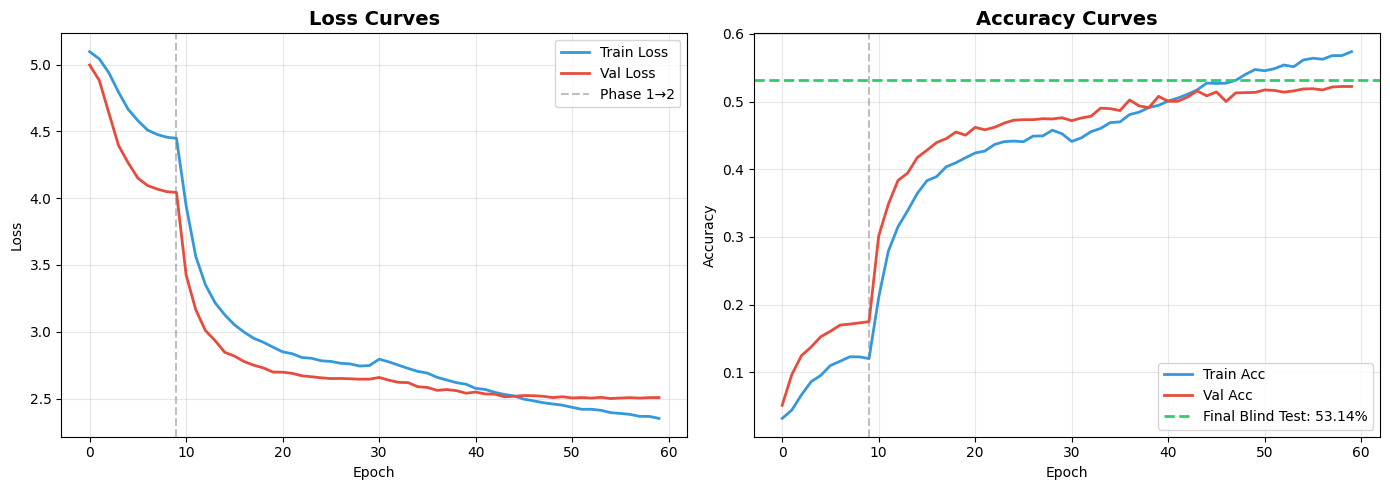

🏆 Best Val Acc: 0.522 (52.24%)
📊 Final Blind Test Acc: 0.531 (53.14%)
💾 Plot saved to checkpoints_improved/training_history.png


In [15]:
# ==========================================
# CELL 16: PLOT TRAINING HISTORY
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='#e74c3c', linewidth=2)
axes[0].axvline(x=PHASE1_EPOCHS-1, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
axes[0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(train_accs, label='Train Acc', color='#3498db', linewidth=2)
axes[1].plot(val_accs, label='Val Acc', color='#e74c3c', linewidth=2)
axes[1].axhline(y=test_acc, color='#2ecc71', linestyle='--', linewidth=2, label=f'Final Blind Test: {test_acc:.2%}')
axes[1].axvline(x=PHASE1_EPOCHS-1, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, 'training_history.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"🏆 Best Val Acc: {best_val_acc:.3f} ({best_val_acc:.2%})")
print(f"📊 Final Blind Test Acc: {test_acc:.3f} ({test_acc:.2%})")
print(f"💾 Plot saved to {plot_path}")

In [ ]:
# ==========================================
# CELL 17: INTERACTIVE INFERENCE (WITH TTA)
# ==========================================
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets

class VQAPredictor:
    def __init__(self, ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        self.a2i = ckpt['answer_to_idx']
        self.i2a = ckpt['idx_to_answer']
        self.model = VQAModel(len(self.a2i)).to(DEVICE)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.model.eval()
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
        print(f"✅ Model loaded: {len(self.a2i)} semantic groups | Val Acc during training: {ckpt.get('val_acc', 0):.2%}")
    
    def predict(self, image_path, question, top_k=5, use_tta=True):
        image = Image.open(image_path).convert('RGB')
        tokens = self.tokenizer(question, max_length=MAX_QUESTION_LENGTH, padding='max_length', truncation=True, return_tensors='pt')
        
        tta_transforms = [self.transform] if not use_tta else [
            self.transform,
            transforms.Compose([transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)), transforms.CenterCrop(IMG_SIZE), transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])]),
        ]
        
        all_probs = []
        with torch.no_grad():
            for tform in tta_transforms:
                img = tform(image).unsqueeze(0).to(DEVICE)
                logits = self.model(img, tokens['input_ids'].to(DEVICE), tokens['attention_mask'].to(DEVICE))
                all_probs.append(torch.softmax(logits, dim=1))
        
        avg_probs = torch.stack(all_probs).mean(dim=0)
        top_probs, top_idx = torch.topk(avg_probs, top_k, dim=1)
        return [{'answer': self.i2a.get(top_idx[0][i].item(), '<unk>'), 'confidence': top_probs[0][i].item()} for i in range(top_k)]

# Load predictor
if os.path.exists(BEST_MODEL_PATH):
    predictor = VQAPredictor(BEST_MODEL_PATH)
    
    print(f"\n💡 Try questions like: 'What is the weather?', 'What color is the bus?', 'How many people?'\n")
    
    uploader = widgets.FileUpload(accept='image/*', multiple=False, description='📁 Upload', button_style='info')
    text_q = widgets.Text(value="What is the weather?", description="Question:", layout=widgets.Layout(width='50%'))
    btn = widgets.Button(description="🎯 Ask", button_style='success')
    out = widgets.Output()
    
    def on_click(b):
        with out:
            clear_output()
            if not uploader.value: print("⚠️ Upload an image!"); return
            q = text_q.value.strip()
            if not q: print("⚠️ Type a question!"); return
            print(f"🤔 Q: '{q}'")
            try:
                data = uploader.value
                content = data[0]['content'] if isinstance(data, (tuple, list)) else list(data.values())[0]['content']
                with open("temp_vqa.jpg", "wb") as f: f.write(content)
                display(IPImage(data=content, width=400))
                results = predictor.predict("temp_vqa.jpg", q, top_k=5)
                print("\n" + "="*50 + "\n🏆 TOP 5 PREDICTIONS:\n" + "="*50)
                medals = ['🥇','🥈','🥉','4️⃣','5️⃣']
                for i, r in enumerate(results):
                    bar = '█' * int(r['confidence'] * 25)
                    print(f"{medals[i]} {r['answer']:<25} {r['confidence']:.1%} {bar}")
                print("="*50)
            except Exception as e: print(f"❌ Error: {e}")
    
    btn.on_click(on_click)
    display(widgets.VBox([widgets.HBox([uploader, text_q]), btn, out]))
else:
    print(f"⚠️ Model not found at {BEST_MODEL_PATH}. Train first!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded: 375 semantic groups | Val Acc during training: 52.24%

💡 Try questions like: 'What is the weather?', 'What color is the bus?', 'How many people?'



: 

In [4]:
# ==========================================
# CELL 17: STANDALONE INFERENCE (INTERACTIVE WIDGET)
# ==========================================
"""
STANDALONE VQA INFERENCE
Run this cell independently after training is complete.
No need to run any other cells!
"""

import torch, torch.nn as nn
import torchvision.models as models, torchvision.transforms as transforms
from transformers import DistilBertTokenizer, DistilBertModel
from PIL import Image
import os, json, random, glob, warnings
import numpy as np
from IPython.display import display, clear_output, Image as IPImage
import ipywidgets as widgets
warnings.filterwarnings('ignore')

# ==========================================
# CONFIGURATION
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = "checkpoints_improved"
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model_newdata_Copy.pt")

IMG_SIZE = 224
MAX_QUESTION_LENGTH = 64
FUSION_HIDDEN = 512
DROPOUT = 0.6

# ==========================================
# MODEL ARCHITECTURE (Matches Training Cells)
# ==========================================
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        m = models.mobilenet_v3_large(weights=None)
        self.features = m.features
        self.avgpool = m.avgpool
        self.projection = nn.Sequential(
            nn.Linear(960, FUSION_HIDDEN),
            nn.LayerNorm(FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.projection(x)

class TextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.projection = nn.Sequential(
            nn.Linear(768, FUSION_HIDDEN),
            nn.LayerNorm(FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT)
        )
    
    def forward(self, input_ids, attention_mask):
        return self.projection(
            self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        )

class FusionLayer(nn.Module):
    """Element-wise fusion: v*t, v, t concatenated."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FUSION_HIDDEN * 3, FUSION_HIDDEN),
            nn.LayerNorm(FUSION_HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(FUSION_HIDDEN, FUSION_HIDDEN // 2),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(FUSION_HIDDEN // 2, FUSION_HIDDEN // 2)
        )
    
    def forward(self, v, t):
        return self.net(torch.cat([v * t, v, t], dim=1))

class VQAModel(nn.Module):
    def __init__(self, num_answers):
        super().__init__()
        self.cnn = CNNEncoder()
        self.text = TextEncoder()
        self.fusion = FusionLayer()
        self.classifier = nn.Linear(FUSION_HIDDEN // 2, num_answers)
    
    def forward(self, image, input_ids, attention_mask):
        return self.classifier(
            self.fusion(self.cnn(image), self.text(input_ids, attention_mask))
        )

# ==========================================
# LOAD MODEL
# ==========================================
print("="*60)
print("🔄 LOADING TRAINED VQA MODEL")
print("="*60)

if not os.path.exists(BEST_MODEL_PATH):
    ckpts = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "*.pt")), key=os.path.getmtime, reverse=True)
    if ckpts:
        BEST_MODEL_PATH = ckpts[0]
        print(f"📁 Using: {BEST_MODEL_PATH}")
    else:
        raise FileNotFoundError(f"No model in {CHECKPOINT_DIR}! Train first.")

ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
answer_to_idx = ckpt['answer_to_idx']
idx_to_answer = ckpt['idx_to_answer']
num_classes = ckpt['vocab_size']

print(f"✅ Loaded | Classes: {num_classes} | Val Acc: {ckpt.get('val_acc',0):.2%}")

model = VQAModel(num_classes).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# ==========================================
# PREDICT FUNCTION
# ==========================================
def predict(image_path, question, top_k=5, use_tta=True):
    image = Image.open(image_path).convert('RGB')
    tokens = tokenizer(question, max_length=MAX_QUESTION_LENGTH, padding='max_length', truncation=True, return_tensors='pt')
    
    tta = [transform]
    if use_tta:
        tta.append(transforms.Compose([
            transforms.Resize((IMG_SIZE+16,IMG_SIZE+16)), transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ]))
    
    probs = []
    with torch.no_grad():
        for tform in tta:
            img = tform(image).unsqueeze(0).to(DEVICE)
            logits = model(img, tokens['input_ids'].to(DEVICE), tokens['attention_mask'].to(DEVICE))
            probs.append(torch.softmax(logits, dim=1))
    
    avg = torch.stack(probs).mean(dim=0)
    vals, idxs = torch.topk(avg, top_k, dim=1)
    return [{'answer': idx_to_answer.get(idxs[0][i].item(),'<unk>'), 'confidence': vals[0][i].item()} for i in range(top_k)]

# ==========================================
# INTERACTIVE WIDGET
# ==========================================
SUGGESTED = [
    "What color is the bus?", "What type of scene is this?",
    "Where is the bus located?", "How many buses are there?",
    "What is the weather?", "What is happening?",
    "What time of day is it?", "What is the main object?",
    "What is the atmosphere?", "Is there a person visible?"
]

print(f"\n💡 SUGGESTED QUESTIONS:")
for i, q in enumerate(SUGGESTED):
    print(f"   {i+1:2d}. {q}")

uploader = widgets.FileUpload(accept='image/*', multiple=False, description='📁 Upload', button_style='info')
text_q = widgets.Text(value="What is the weather?", description="Question:", layout=widgets.Layout(width='50%'))
btn = widgets.Button(description="🎯 Ask Model", button_style='success')
out = widgets.Output()

def on_click(b):
    with out:
        clear_output()
        if not uploader.value: print("⚠️ Upload an image!"); return
        q = text_q.value.strip()
        if not q: print("⚠️ Type a question!"); return
        print(f"🤔 Q: '{q}'")
        try:
            data = uploader.value
            content = data[0]['content'] if isinstance(data,(tuple,list)) else list(data.values())[0]['content']
            with open("_tmp_vqa.jpg","wb") as f: f.write(content)
            display(IPImage(data=content, width=400))
            results = predict("_tmp_vqa.jpg", q, top_k=5)
            print("\n"+"="*50+"\n🏆 TOP 5:\n"+"="*50)
            for i, r in enumerate(results):
                bar = '█'*int(r['confidence']*25)
                print(f"{['🥇','🥈','🥉','4️⃣','5️⃣'][i]} {r['answer']:<25} {r['confidence']:>6.1%} {bar}")
            print("="*50+f"\n💡 Try: '{random.choice(SUGGESTED)}'")
        except Exception as e: print(f"❌ {e}")

btn.on_click(on_click)
display(widgets.VBox([widgets.HBox([uploader, text_q]), btn, out]))
print("\n"+"="*60+"\n✅ READY! Upload an image and ask a question.\n"+"="*60)

🔄 LOADING TRAINED VQA MODEL
✅ Loaded | Classes: 375 | Val Acc: 52.24%


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



💡 SUGGESTED QUESTIONS:
    1. What color is the bus?
    2. What type of scene is this?
    3. Where is the bus located?
    4. How many buses are there?
    5. What is the weather?
    6. What is happening?
    7. What time of day is it?
    8. What is the main object?
    9. What is the atmosphere?
   10. Is there a person visible?



✅ READY! Upload an image and ask a question.
